# DATA 620
## Document Classification
### Kevin Havis & Aaliyah John-Harry

## Introduction

For our assignment, we used the Spam Emails dataset from Kaggle (https://www.kaggle.com/datasets/venky73/spam-mails-dataset
) to build and evaluate a machine learning model for classifying emails as either spam or ham (non-spam).

We first preprocessed the data by cleaning and standardizing the email text, including steps such as lowercasing, removing punctuation, and filtering out common stopwords. This allowed us to focus on the most meaningful words and patterns within each message. The text data was then transformed into numerical features using TF-IDF vectorization, which captures the relative importance of words across the dataset.

Using these features, we trained multiple classification models, including Naive Bayes and Logistic Regression, to learn patterns that distinguish spam from legitimate emails. The dataset was split into training and testing sets to evaluate how well each model generalizes to unseen data.

We will use these models to compare performance across different evaluation metrics, identify the most effective approach for spam detection, and demonstrate how natural language processing techniques can be applied to real-world filtering problems.

## Data Loading

For a simple dataset, the EDA is straightforward. 

We load the spam email dataset and perform some initial checks to understand its structure better.
- The dataset contains 5,171 emails with three columns:
    - the text of the email
    - its label (spam or ham)
    - a numerical version of the label for modeling.

Conveniently, the ham / spam label has already been encoded as 0 / 1 for us in the `label_num` column.

In [3]:
from pathlib import Path

if Path("spam_ham_dataset.csv").exists():
    file_path = Path("spam_ham_dataset.csv")
else:
    file_path = Path("assignment6/spam_ham_dataset.csv")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(file_path, index_col=0)

print(df.shape)
print(df["label"].value_counts())
df.head(10)

(5171, 3)
label
ham     3672
spam    1499
Name: count, dtype: int64


,label,text,label_num
605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
4685,spam,"Subject: photoshop , windows , office . cheap ...",1
2030,ham,Subject: re : indian springs\r\nthis deal is t...,0
2949,ham,Subject: ehronline web address change\r\nthis ...,0
2793,ham,Subject: spring savings certificate - take 30 ...,0
4185,spam,Subject: looking for medication ? we ` re the ...,1
2641,ham,Subject: noms / actual flow for 2 / 26\r\nwe a...,0
1870,ham,"Subject: nominations for oct . 21 - 23 , 2000\...",0


For any classification task, it is critical to understand the proportions of each target class. This proportion acts as a "prior" or ground truth which helps us contextualize our model results. Especially in the case of spam mail, where most emails are likely not spam, a model could "cheat" by simply predicting the more common value. This is referre to as class imbalance.

Looking at the class distribution, we can see that there are more ham (non-spam) emails than spam emails (3,672 vs. 1,499). Given we have this skew, we will need to address in our training and modeling by being selective in our scoring methods.

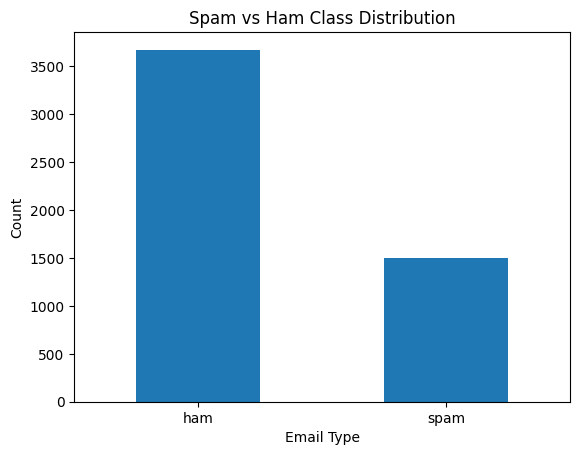

In [5]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Spam vs Ham Class Distribution")
plt.xlabel("Email Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Finally, we confirm there's no nulls in this dataset. There are none.

In [6]:
print(df.columns)
print(df.isnull().sum())

Index(['label', 'text', 'label_num'], dtype='object')
label        0
text         0
label_num    0
dtype: int64


## Data Preprocessing

In [7]:
import re
import string
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
STOPWORDS = set(stopwords.words("english"))


def preprocess(text):
    text = text.lower()
    text = re.sub(r"subject:\s*", "", text)  # strip email subject prefix
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and t.isalpha()]
    return " ".join(tokens)


df["clean_text"] = df["text"].apply(preprocess)
df[["text", "clean_text"]].head(3)

,text,clean_text
605,Subject: enron methanol ; meter # : 988291\r\n...,enron methanol meter follow note gave monday p...
2349,"Subject: hpl nom for january 9 , 2001\r\n( see...",hpl nom january see attached file hplnol xls h...
3624,"Subject: neon retreat\r\nho ho ho , we ' re ar...",neon retreat ho ho ho around wonderful time ye...



As with much text analysis, it is useful to do some preprocessing. We will remove the extraneous metadata text indicating "subject" and remove common stop words, using `NLTK`'s default set. We will also convert the text into tokens by splitting into monograms (single words).


We cleaned and standardized the raw email text to make it more suitable for modeling.
- First, all text was converted to lowercase to ensure consistency and avoid treating the same word differently due to capitalization.
- We also removed the “Subject:” prefix, since it appears frequently in emails but doesn’t add meaningful value for classification.
- Next, punctuation was stripped out, and the text was split into individual words (tokens).
- We then removed common English stopwords (such as “the”, “and”, “is”), as well as any non-alphabetic tokens, to reduce noise and focus on more meaningful words.
- The cleaned tokens were then joined back into a single string and stored in a new column called clean_text.

Comparing the original and cleaned text shows that unnecessary elements have been removed, leaving behind a more concise representation of each email that is better suited for feature extraction and model training.

## Feature Engineering

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10_000)
X = vectorizer.fit_transform(df["clean_text"])
y = df["label_num"]

print(f"Feature matrix: {X.shape}")

Feature matrix: (5171, 10000)


After applying TF-IDF vectorization, the text data was converted into a feature matrix with shape (5171, 10000). This means we have 5,171 emails, and each one is represented by 10,000 word-based features.

- Each feature corresponds to a word from the dataset, and the values represent how important that word is within a specific email compared to the rest of the dataset.
    - Words that are more unique to certain emails (and not common across all emails) are given higher weights, which helps the model better distinguish between spam and non-spam messages.
- By limiting the feature space to the top 10,000 words, we kept the most informative terms while avoiding unnecessary complexity.
    - This makes the model more efficient while still capturing enough detail to learn meaningful patterns in the data.

## Train/Test Split

With feature engineering complete, we can train our models. First, to prevent overfitting, we will create a train-test set split. As mentioned earlier, the class imbalance will need to be addressed; to do so, we can simply stratify the split by the target variable to ensure there is equal representation in both populations.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")

Train: 4136  Test: 1035


## Model Building

We have an array of classification models available to us. We will use the very common Naives Bayes classifier, a logistic regression, and a Random Forest as our options.

In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)

## Model Evaluation

With models trained, we evaluate their performance on the holdout test data. As mentioned we cannot use simple accuracy; given we are building a spam filter, we must keep the below in mind;

- We penalize False Positives more punitively, as Letting a spam message pass the filter is likely less damaging than incorrectly filtering a real email
- Accuracy at minimum should be similar to the proportions we observed earlier; overall it is not the ideal metric for this problem
- As such, our model should prioritize precision, meaning it is rarely wrong when it predicts spam.
  
With this in mind, we make our test predictions and visualize the results as a confusion matrix.

=== Naive Bayes ===
              precision    recall  f1-score   support

         ham       0.97      0.98      0.97       735
        spam       0.95      0.91      0.93       300

    accuracy                           0.96      1035
   macro avg       0.96      0.95      0.95      1035
weighted avg       0.96      0.96      0.96      1035

=== Logistic Regression ===
              precision    recall  f1-score   support

         ham       1.00      0.98      0.99       735
        spam       0.96      0.99      0.98       300

    accuracy                           0.99      1035
   macro avg       0.98      0.99      0.98      1035
weighted avg       0.99      0.99      0.99      1035

=== Random Forest ===
              precision    recall  f1-score   support

         ham       0.99      0.97      0.98       735
        spam       0.93      0.98      0.95       300

    accuracy                           0.97      1035
   macro avg       0.96      0.98      0.97      1035
weig

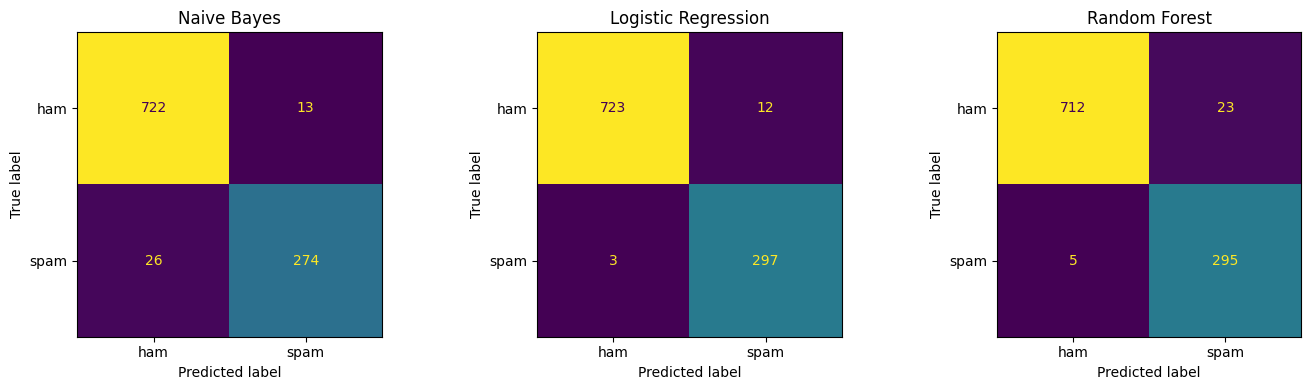

In [11]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = report
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

# Confusion matrices
fig, axes = plt.subplots(1, len(models), figsize=(14, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(
        ax=ax, colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

                     precision    recall  f1-score
Naive Bayes           0.962186  0.962319  0.962067
Logistic Regression   0.985809  0.985507  0.985570
Random Forest         0.974083  0.972947  0.973173


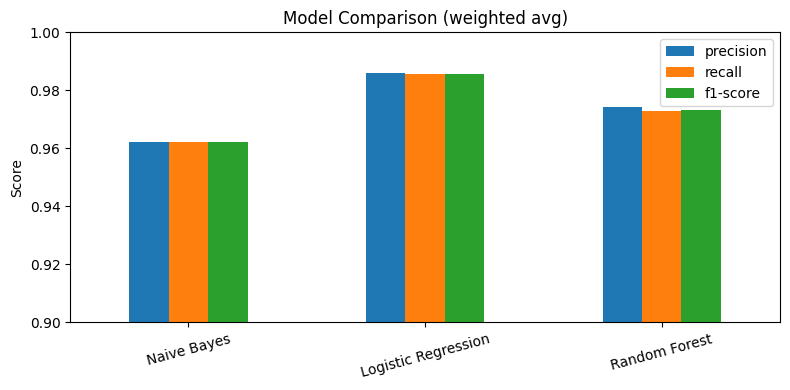


Best model by F1: Logistic Regression


In [12]:
metrics = ["precision", "recall", "f1-score"]
summary = pd.DataFrame(
    {name: {m: results[name]["weighted avg"][m] for m in metrics} for name in results}
).T

print(summary.to_string())

summary.plot(kind="bar", figsize=(8, 4), ylim=(0.9, 1.0))
plt.title("Model Comparison (weighted avg)")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best = summary["f1-score"].idxmax()
print(f"\nBest model by F1: {best}")

Reviewing the performance across the models, logistic regression is the clear winner. It is the simplest model, is easily explainable, and also performs the best in almost all metrics, but especially in precision with regards to `ham` labels - real emails that we don't want to accidentally filter out.

## Conclusion

In this assignment, we built and evaluated multiple machine learning models to classify emails as spam or ham using NLP techniques. After cleaning and preprocessing the text data, we transformed it into numerical features using TF-IDF, which allowed the models to learn meaningful patterns in word usage.

Across all models, performance was strong, with high accuracy and F1-scores. However, Logistic Regression performed the best overall, achieving the highest F1-score and showing a strong balance between precision and recall. This suggests that it was most effective at correctly identifying both spam and non-spam emails, while minimizing misclassifications.

While Naive Bayes and Random Forest also performed well, they showed slightly weaker performance in comparison, particularly in handling certain misclassifications, as seen in the confusion matrices.

Because the dataset contains more ham than spam emails, accuracy alone can be misleading, as a model could achieve high accuracy by simply predicting the majority class. Instead, we focus on precision and recall to better evaluate how well the model identifies spam emails and avoids misclassifying legitimate messages.